**Introduction to time series forecasting with statistical models:**
- dependencies: statsforecast

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *
import warnings
warnings.filterwarnings("ignore")

Initial setup:

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/marcopeix/youtube_tutorials/refs/heads/main/data/daily_sales_french_bakery.csv",
                 parse_dates=['ds'])

In [8]:
df.shape

(57046, 4)

In [10]:
# taking the series with more than 28 timesteps
df = df.groupby('unique_id').filter(lambda x: len(x) >= 28)
df = df.drop(['unit_price'], axis=1)
df.head()

,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0


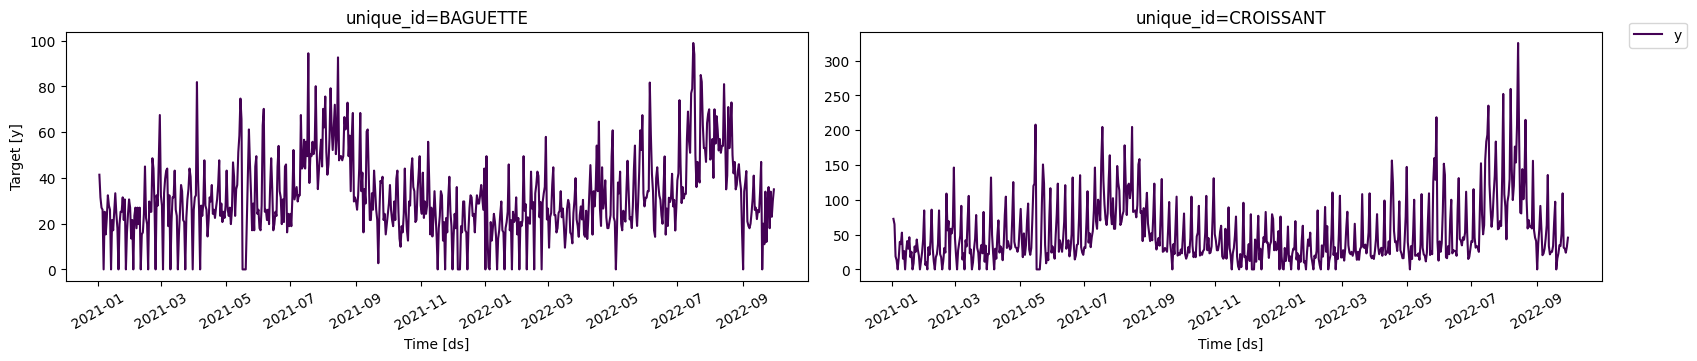

In [ ]:
plot_series(df=df,ids=['BAGUETTE','CROISSANT'], palette='viridis') # ids looks for a col named unique_id in your dataset and expects the time column to be named ds

In [12]:
plot_series?

Signature:
plot_series(
    df: Optional[pandas.core.frame.DataFrame] = None,
    forecasts_df: Optional[pandas.core.frame.DataFrame] = None,
    ids: Optional[List[str]] = None,
    plot_random: bool = True,
    max_ids: int = 8,
    models: Optional[List[str]] = None,
    level: Optional[List[float]] = None,
    max_insample_length: Optional[int] = None,
    plot_anomalies: bool = False,
    engine: str = 'matplotlib',
    palette: Optional[str] = None,
    id_col: str = 'unique_id',
    time_col: str = 'ds',
    target_col: str = 'y',
    seed: int = 0,
    resampler_kwargs: Optional[Dict] = None,
    ax: Union[matplotlib.axes._axes.Axes, numpy.ndarray, ForwardRef('plotly.graph_objects.Figure'), NoneType] = None,
)
Docstring:
Plot forecasts and insample values.

Args:
    df (pandas or polars DataFrame, optional): DataFrame with columns
        [`id_col`, `time_col`, `target_col`]. Defaults to None.
    forecasts_df (pandas or polars DataFrame, optional): DataFrame with
        colu

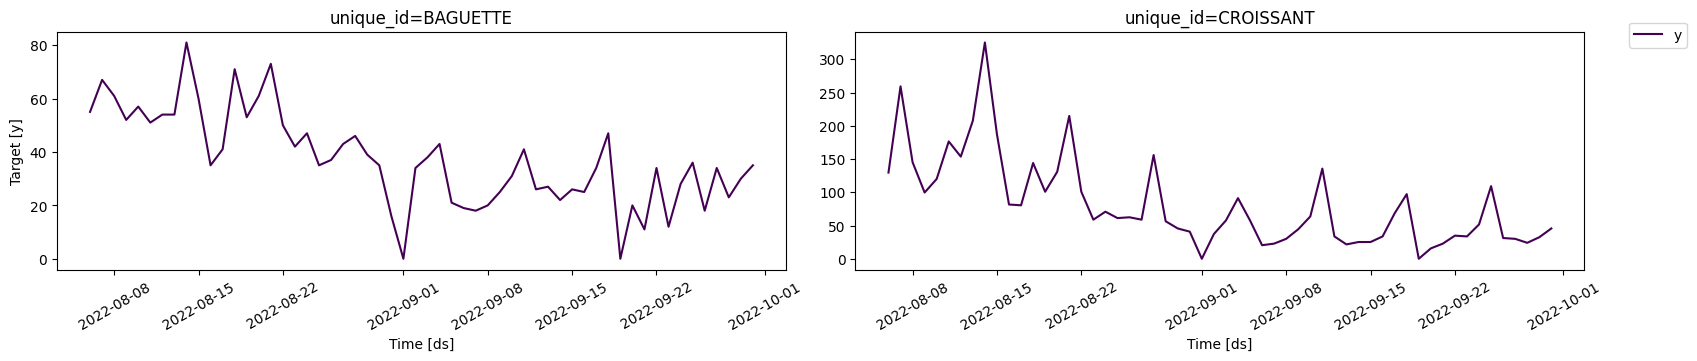

In [14]:
# plotting the last 56 timesteps
plot_series(df=df, ids=["BAGUETTE","CROISSANT"], max_insample_length=56, palette="viridis")

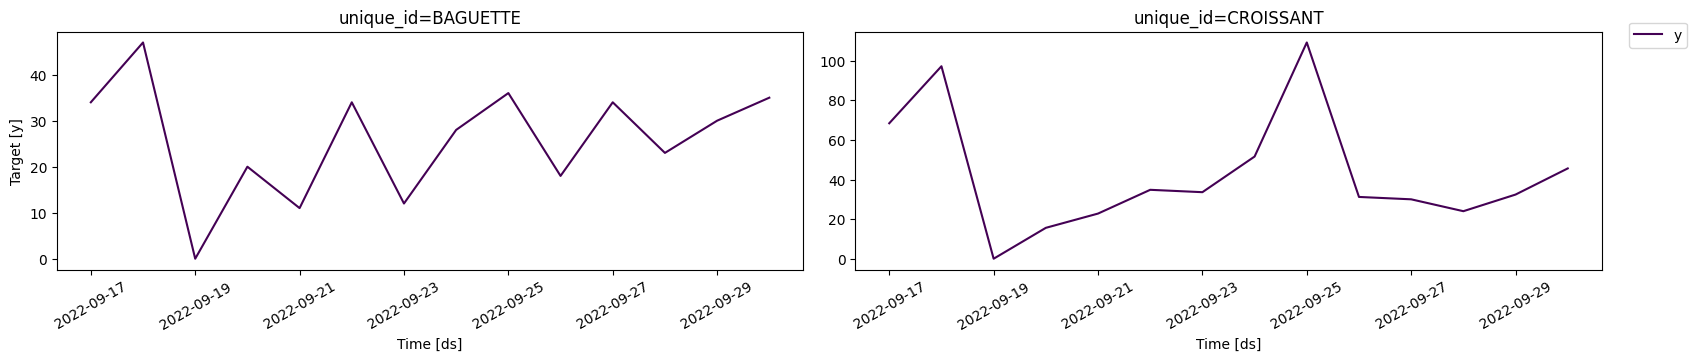

In [16]:
# plotting the last 56 timesteps
plot_series(df=df, ids=["BAGUETTE","CROISSANT"], max_insample_length=14, palette="viridis")

Baseline models:

In [15]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
# Naive: all forecasts have the value of the last observation, HistoricAverage: simple average of all past observations
# WindowAverage: uses the average of the last k-observations with k the length of the window
# SeasonalNaive: similar to naive but uses the last known observation of the same period (e.g. the same month of the previous year)

In [ ]:
horizon = 7 # forecasting horizon - 7 days ahead

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7) # assuming weakly seasonality - seasonality every 7 days timeseries repeats every season_length periods
]

sf = StatsForecast(models=models, freq="D")

sf.fit(df=df)

preds = sf.predict(h=horizon)

In [18]:
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-29,10.0,8.974359,2.857143,0.0
1,12 MACARON,2022-09-30,10.0,8.974359,2.857143,0.0
2,12 MACARON,2022-10-01,10.0,8.974359,2.857143,10.0
3,12 MACARON,2022-10-02,10.0,8.974359,2.857143,0.0
4,12 MACARON,2022-10-03,10.0,8.974359,2.857143,0.0


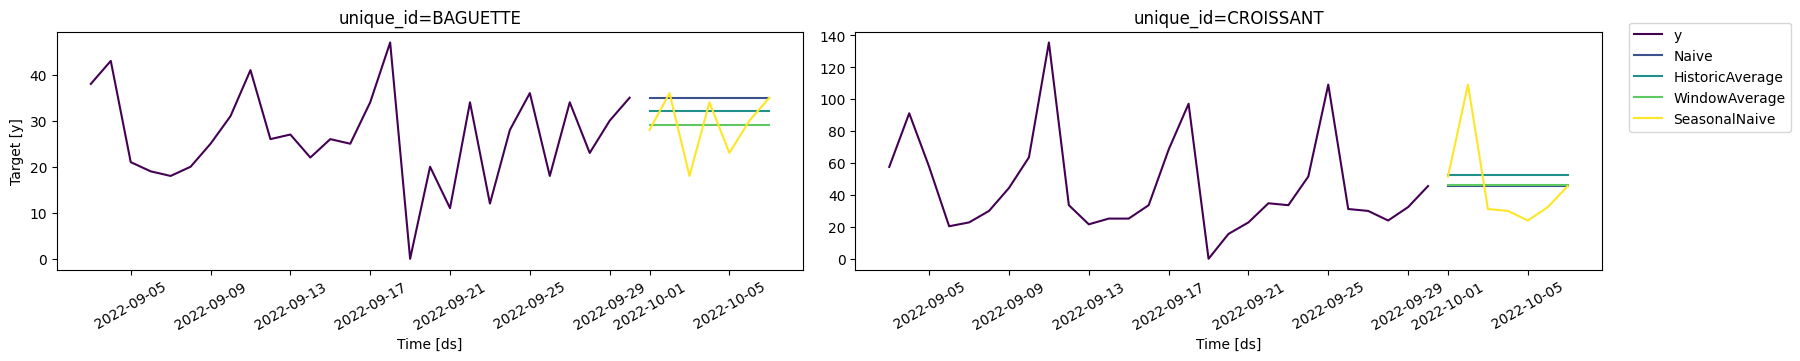

In [19]:
plot_series(
    df=df,
    forecasts_df=preds,
    ids=["BAGUETTE","CROISSANT"],
    max_insample_length=28,
    palette="viridis"
)

evaluate baseline models:

In [20]:
test = df.groupby("unique_id").tail(7)
train = df.drop(test.index).reset_index(drop=True)

In [21]:
train.head()

,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0


In [22]:
sf.fit(df=train)
preds = sf.predict(h=horizon)
eval_df = pd.merge(test, preds, 'left', ['ds','unique_id'])

In [23]:
eval_df.head()

,unique_id,ds,y,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-22,0.0,0.0,9.577465,1.428571,10.0
1,12 MACARON,2022-09-23,0.0,0.0,9.577465,1.428571,0.0
2,12 MACARON,2022-09-24,10.0,0.0,9.577465,1.428571,0.0
3,12 MACARON,2022-09-25,0.0,0.0,9.577465,1.428571,0.0
4,12 MACARON,2022-09-26,0.0,0.0,9.577465,1.428571,0.0


In [24]:
evaluation = evaluate(
    eval_df,
    metrics=[mae],
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,2.857143,6.961771,3.469388,4.285714
1,BAGUETTE,mae,17.142857,5.455193,7.877551,12.571429
2,BAGUETTE APERO,mae,0.000000,0.537572,0.642857,0.642857
3,BAGUETTE GRAINE,mae,9.800000,4.612271,2.942857,0.200000
4,BANETTE,mae,1.314286,5.421984,6.008163,7.885714


In [25]:
evaluation = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.107556,5.228439,5.011663,4.613636


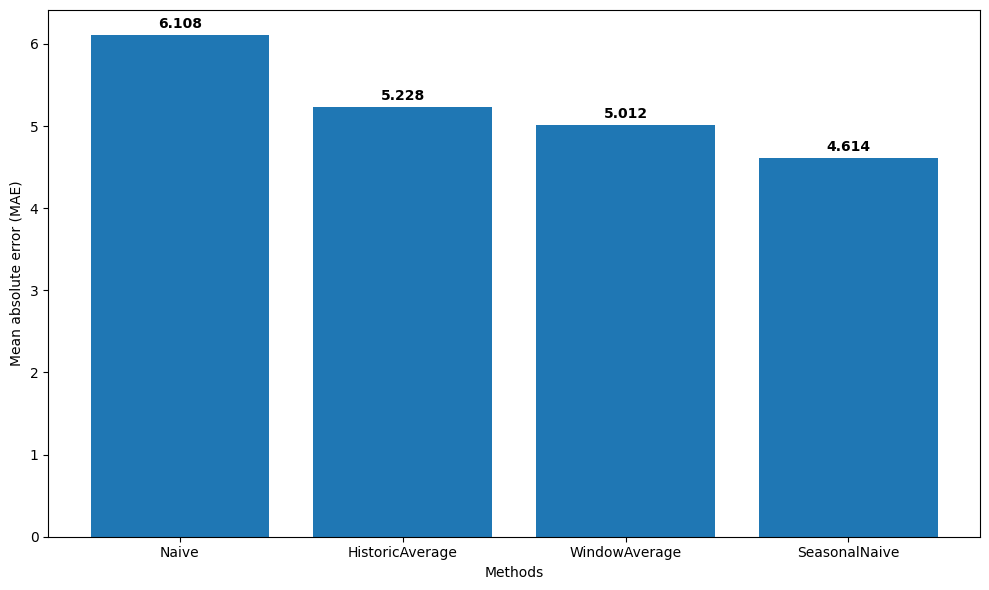

In [26]:
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0,1:].tolist()

plt.figure(figsize=(10,6))
bars = plt.bar(methods,values)

for bar, value in zip(bars,values):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.05,f'{value:.3f}',ha='center',va='bottom',fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

seasonal naive seems to be the best baseline in this case...

In [28]:
plot_series?

Signature:
plot_series(
    df: Optional[pandas.core.frame.DataFrame] = None,
    forecasts_df: Optional[pandas.core.frame.DataFrame] = None,
    ids: Optional[List[str]] = None,
    plot_random: bool = True,
    max_ids: int = 8,
    models: Optional[List[str]] = None,
    level: Optional[List[float]] = None,
    max_insample_length: Optional[int] = None,
    plot_anomalies: bool = False,
    engine: str = 'matplotlib',
    palette: Optional[str] = None,
    id_col: str = 'unique_id',
    time_col: str = 'ds',
    target_col: str = 'y',
    seed: int = 0,
    resampler_kwargs: Optional[Dict] = None,
    ax: Union[matplotlib.axes._axes.Axes, numpy.ndarray, ForwardRef('plotly.graph_objects.Figure'), NoneType] = None,
)
Docstring:
Plot forecasts and insample values.

Args:
    df (pandas or polars DataFrame, optional): DataFrame with columns
        [`id_col`, `time_col`, `target_col`]. Defaults to None.
    forecasts_df (pandas or polars DataFrame, optional): DataFrame with
        colu

In [27]:
df

,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0
...,...,...,...
57041,VIK BREAD,2022-09-26,0.0
57042,VIK BREAD,2022-09-27,0.0
57043,VIK BREAD,2022-09-28,0.0
57044,VIK BREAD,2022-09-29,0.0


picking one variable 12 MACARON

Text(0.5, 1.0, 'MACARON in Aug 2022')

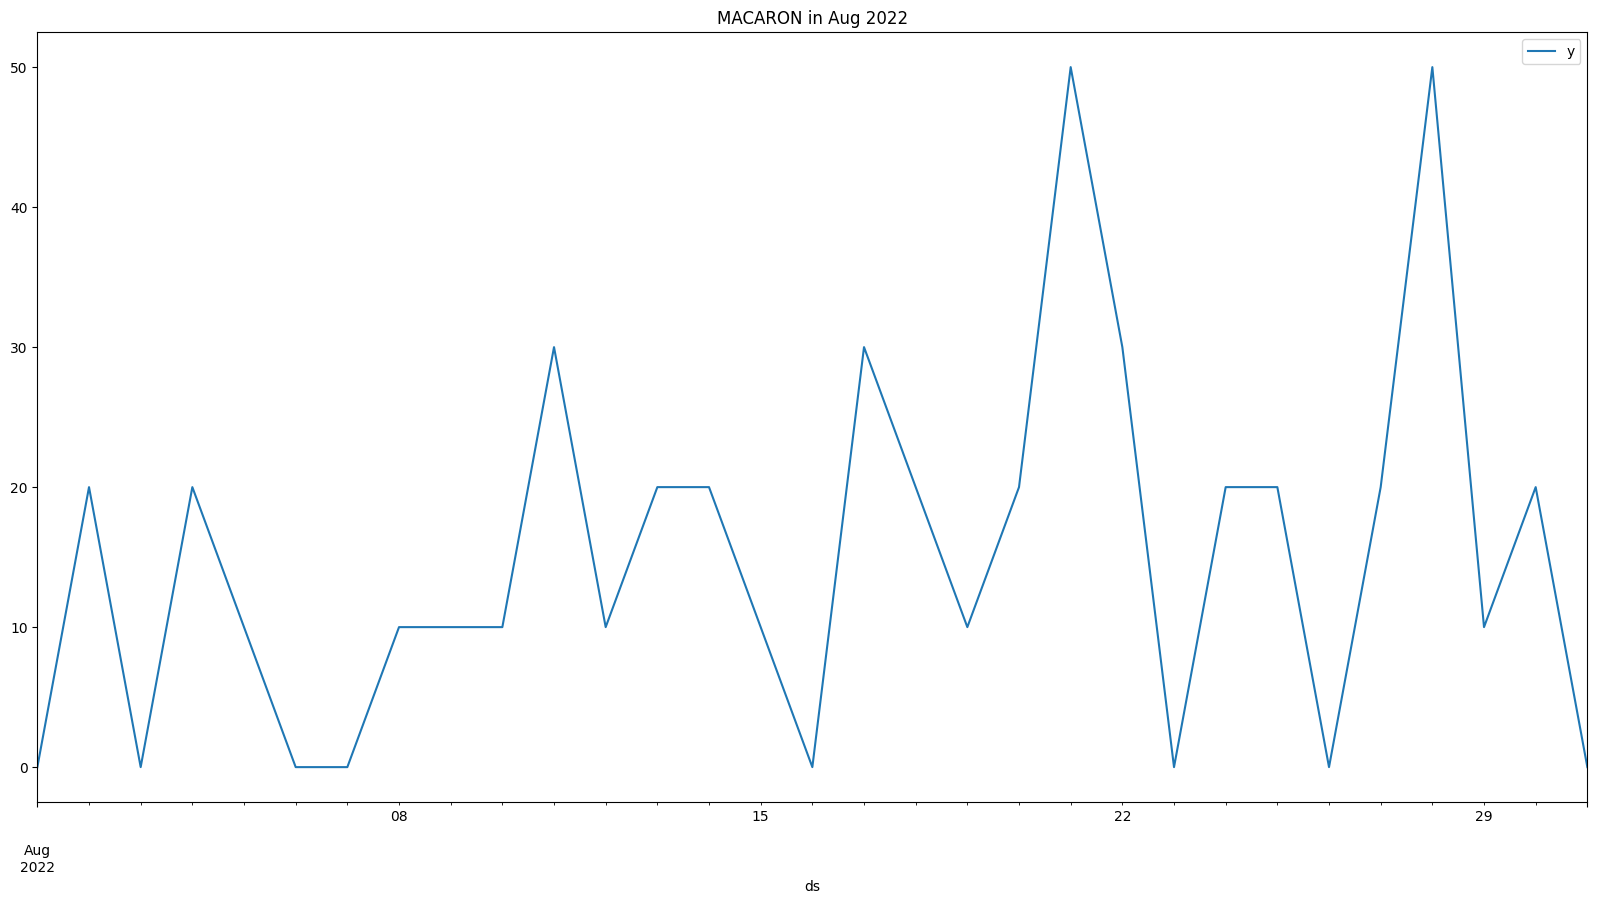

In [ ]:
fig, ax = plt.subplots(figsize=(20,10))
df[(df['unique_id']=='12 MACARON')&((df['ds']>='2022-08-01')&(df['ds']<='2022-08-31'))].plot(ax=ax,kind='line', y='y',x='ds')
ax.set_title('MACARON in Aug 2022')e

Text(0.5, 1.0, 'BAGUETTE in Aug 2022')

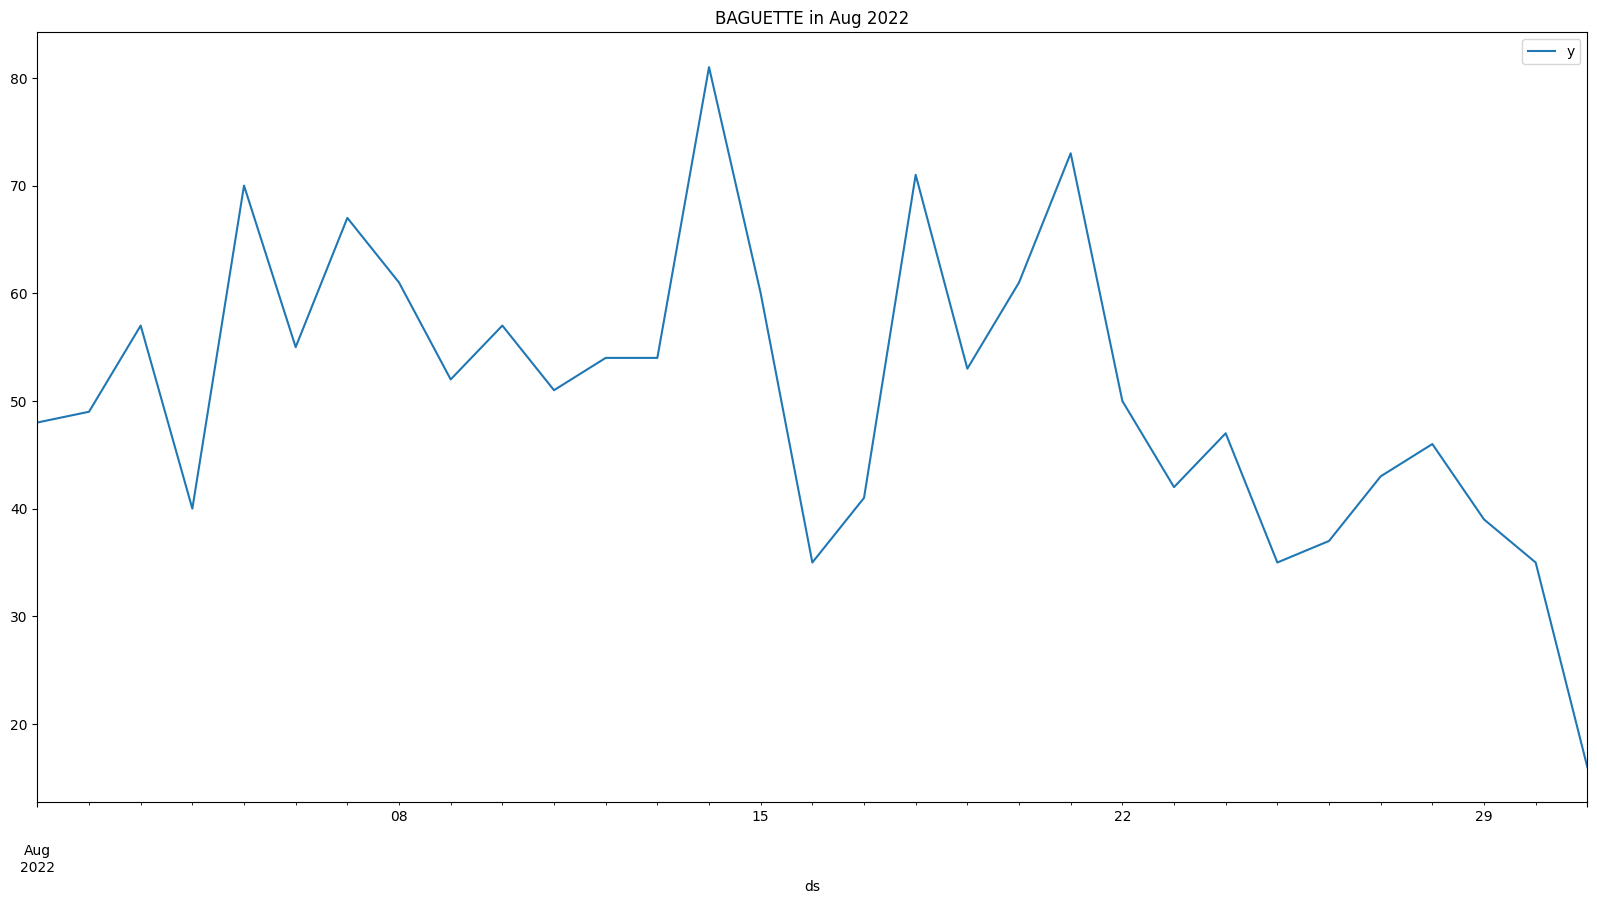

In [36]:
fig, ax = plt.subplots(figsize=(20,10))
df[(df['unique_id']=='BAGUETTE')&((df['ds']>='2022-08-01')&(df['ds']<='2022-08-31'))].plot(ax=ax,kind='line', y='y',x='ds')
ax.set_title('BAGUETTE in Aug 2022')

Text(0.5, 1.0, 'BAGUETTE in Aug 2022')

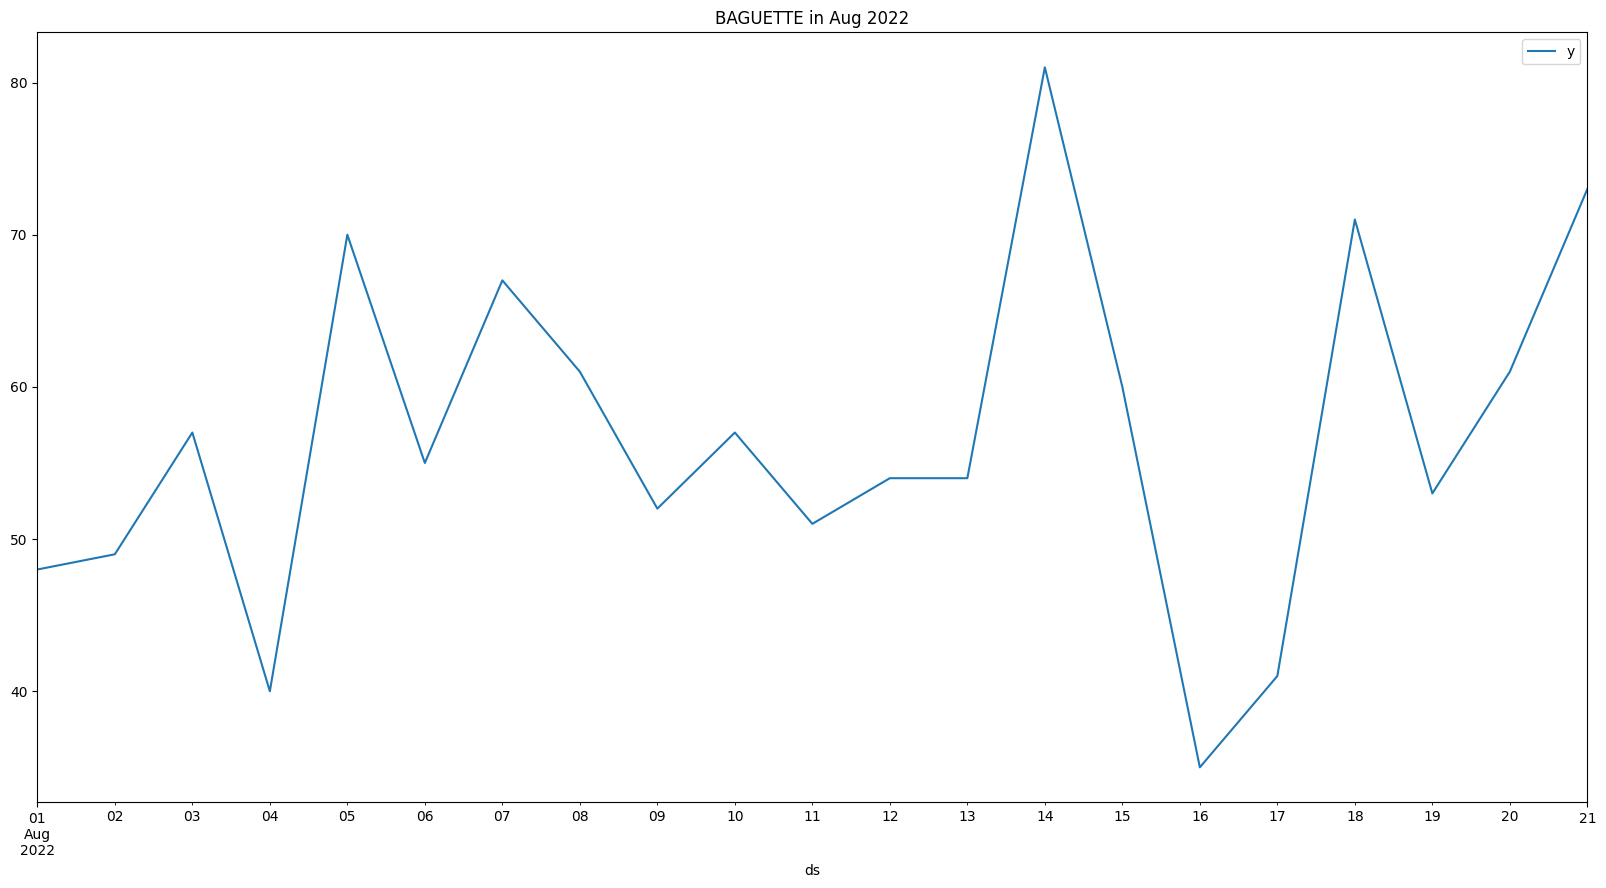

In [37]:
fig, ax = plt.subplots(figsize=(20,10))
df[(df['unique_id']=='BAGUETTE')&((df['ds']>='2022-08-01')&(df['ds']<='2022-08-21'))].plot(ax=ax,kind='line', y='y',x='ds')
ax.set_title('BAGUETTE in Aug 2022')

Text(0.5, 1.0, 'BAGUETTE in Aug 2022')

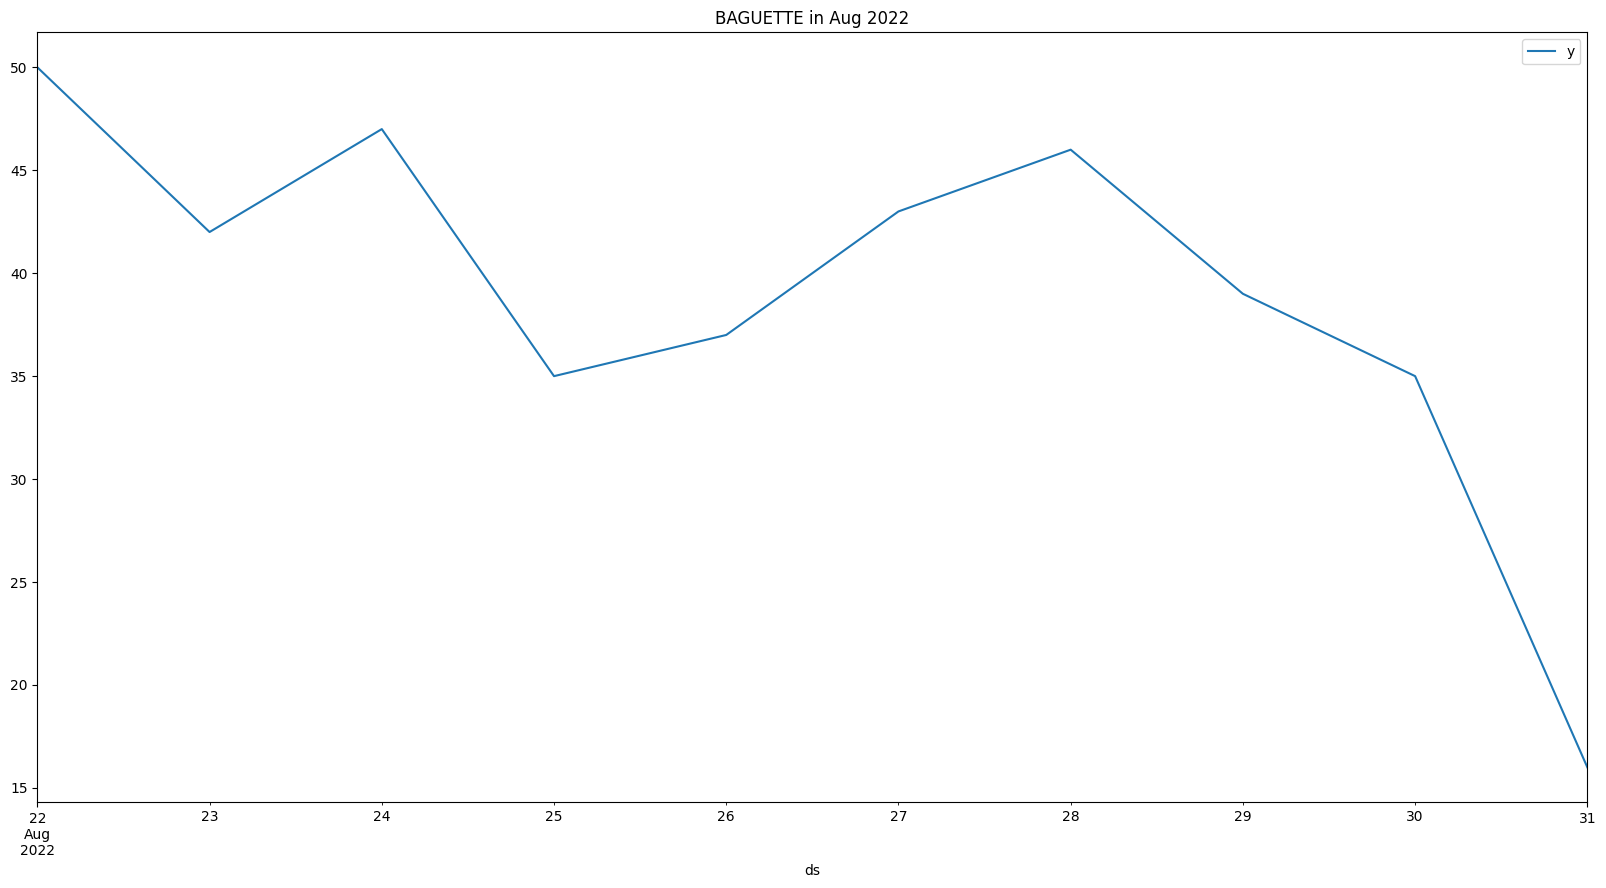

In [38]:
fig, ax = plt.subplots(figsize=(20,10))
df[(df['unique_id']=='BAGUETTE')&((df['ds']>='2022-08-22')&(df['ds']<='2022-08-31'))].plot(ax=ax,kind='line', y='y',x='ds')
ax.set_title('BAGUETTE in Aug 2022')

the closer you look at it - notice subtle seasonality trends. which repeat weekly - pattern repeats every 7 days - the seasonality

In [41]:
baguette_aug1 = df[(df['unique_id']=='BAGUETTE')&((df['ds']>='2022-08-01')&(df['ds']<='2022-08-21'))]
sn = StatsForecast(models=[SeasonalNaive(season_length=7)],freq="D")
sn.fit(df=baguette_aug1)

StatsForecast(models=[SeasonalNaive])

In [42]:
preds_sn = sn.predict(h=14)

In [45]:
predictions_merge = pd.merge(preds_sn,df,'left',['ds','unique_id'])

In [47]:
predictions_merge

,unique_id,ds,SeasonalNaive,y
0,BAGUETTE,2022-08-22,60.0,50.0
1,BAGUETTE,2022-08-23,35.0,42.0
2,BAGUETTE,2022-08-24,41.0,47.0
3,BAGUETTE,2022-08-25,71.0,35.0
4,BAGUETTE,2022-08-26,53.0,37.0
5,BAGUETTE,2022-08-27,61.0,43.0
6,BAGUETTE,2022-08-28,73.0,46.0
7,BAGUETTE,2022-08-29,60.0,39.0
8,BAGUETTE,2022-08-30,35.0,35.0
9,BAGUETTE,2022-08-31,41.0,16.0


<Axes: xlabel='ds'>

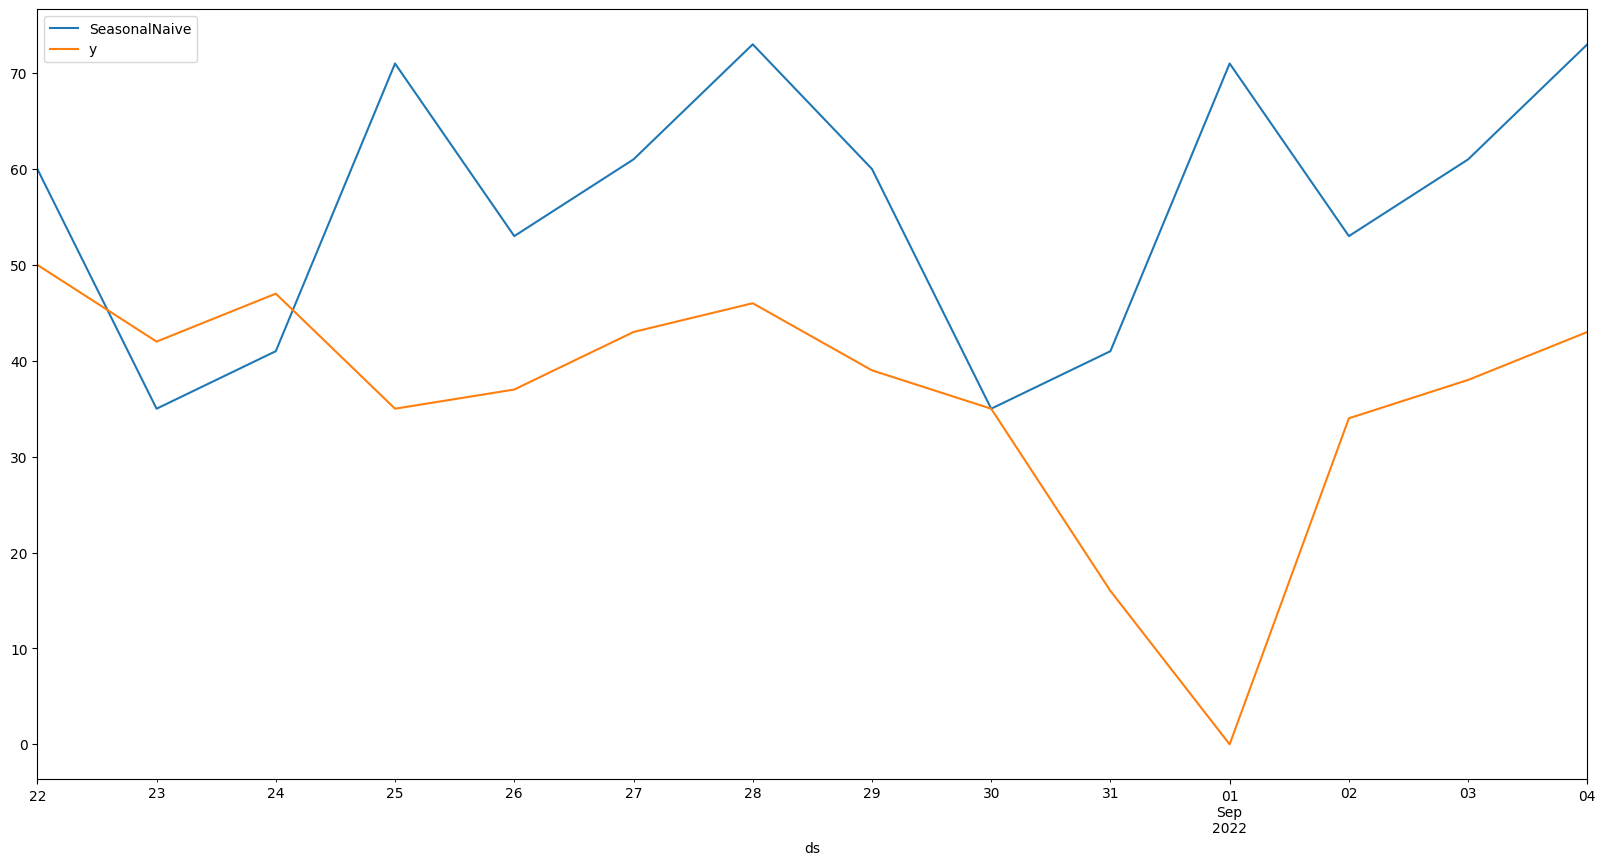

In [49]:
fig, ax = plt.subplots(figsize=(20,10))
predictions_merge.plot(ax=ax,kind='line', x='ds',y=['SeasonalNaive','y'])

seasonal naive does a decent job....

**ARIMA:**
- AR: autoregressive model
- I: order of integration
- MA: moving average model

  - ARIMA: flexible model that can forecast series with a trend and one seasonal period
  - AR: autoregression model | AR(p) predict today using the last p observations
        - if p=2; today = a.yesterday + b.day_before + constant | AR momentum/inertia
        - A regression against itself
        - Future values of the series depend on past values
        - Denoted as AR(p): p is the autoregression order (how many past values we consider)
  - MA: moving average model 
    - MA - use past prediction errors...loosely speaking, MA(q) means correct today's prediction suing the last q mistakes
      - if q=1, today = baseline_prediction + c.(yesterday_error)
        - if yesterday: model predicted 100 | actual was 110 | error = 10, then today's prediction nudges upward
        - MA = error correction
    - FUTURE VALUES depend on the present and past error terms
    - the errors are independent and normally distributed
    - Denoted as MA(q). q : number of error terms you're looking at in the past

  - ARMA : only works for stationary datasets with no seasonality, which is why we use ARIMA
  - I(d) - Integrated : Remove trend by differencing | raw timeseries often trend and AR and MA can't work properly on trending data
    - so (d=1): take the difference between the values (makes the series flat)
    - if (d=2) : taking the difference of the differences now
    - I(d): how many times (d), do I subtract consecutive values to kill the trend
  - ARIMA : AR(p) + I(d) + MA(q) = ARIMA(p,d,q) | d - differencing to remove the trend, predict next change using Last p values (AR) and last q errors (MA)
    - Integration order (I) internally transforms the series to make it stationary
      - Don't have to transform the data ourselves
      - Model can take non-stationary data directly
    - Usually, d is either 0,1,or 2

  - Why ARIMA fails with seasonality: 
    - ARIMA only sees short-term dependence
    - No concept of same time last week
    - leaves structure in the residuals

  - SARIMA: 
    - Do ARIMA but at seasonal lags
    - SARIMA(p,d,q)(P,D,Q,s)
    - s = seasonal period (e.g. 7 for weekly, 12 for yearly)
    - Seasonal I(D) - seasonal differencing | Seasonal AR(P) - same idea for AR(p) but uses values from one season ago | MA(Q) uses errors from one season ago
    - So SARIMA is doing 2 things at once: 
      - Short term behavior 
        - yesterday | day before
      - Seasonal behavior
        - same time last week / month / year
    - think of SARIMA as running 2 ARIMAs in parallel one on recent time and one on seasonal time
  
  - **SARIMA model in practice:**
    - in practice we only have to set m (length of the season) and use AutoARIMA to find the optimal parameter combination

AutoARIMA:

notes:
- we use a subset of the dataset later on because with statistical models when u have multiple series, you are fitting one model per timeseries
- in this case one model per unique_id

In [50]:
from statsforecast.models import AutoARIMA

In [51]:
unique_ids = ["BAGUETTE","CROISSANT"]

small_train = train[train["unique_id"].isin(unique_ids)]
small_test = test[test["unique_id"].isin(unique_ids)]

In [52]:
models = [
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=7, alias="SARIMA")
]

sf = StatsForecast(models=models, freq='D')
sf.fit(df=small_train)

StatsForecast(models=[ARIMA,SARIMA])

In [53]:
eval_df

,unique_id,ds,y,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-22,0.0,0.0,9.577465,1.428571,10.0
1,12 MACARON,2022-09-23,0.0,0.0,9.577465,1.428571,0.0
2,12 MACARON,2022-09-24,10.0,0.0,9.577465,1.428571,0.0
3,12 MACARON,2022-09-25,0.0,0.0,9.577465,1.428571,0.0
4,12 MACARON,2022-09-26,0.0,0.0,9.577465,1.428571,0.0
...,...,...,...,...,...,...,...
842,VIK BREAD,2022-09-26,0.0,24.3,14.590794,11.957143,0.0
843,VIK BREAD,2022-09-27,0.0,24.3,14.590794,11.957143,0.0
844,VIK BREAD,2022-09-28,0.0,24.3,14.590794,11.957143,0.0
845,VIK BREAD,2022-09-29,0.0,24.3,14.590794,11.957143,0.0


In [56]:
arima_eval_df

,unique_id,ds,ARIMA,SARIMA,y,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,BAGUETTE,2022-09-24,31.993511,28.657114,28.0,12.0,32.186349,22.571429,34.0
1,BAGUETTE,2022-09-25,27.865637,42.182374,36.0,12.0,32.186349,22.571429,47.0
2,BAGUETTE,2022-09-26,21.218740,20.013654,18.0,12.0,32.186349,22.571429,0.0
3,BAGUETTE,2022-09-27,13.922878,18.646491,34.0,12.0,32.186349,22.571429,20.0
4,BAGUETTE,2022-09-28,15.029813,16.114926,23.0,12.0,32.186349,22.571429,11.0
5,BAGUETTE,2022-09-29,18.381431,21.288018,30.0,12.0,32.186349,22.571429,34.0
6,BAGUETTE,2022-09-30,24.540427,22.660125,35.0,12.0,32.186349,22.571429,12.0
7,CROISSANT,2022-09-24,39.786586,64.011002,51.6,33.6,52.786508,38.914286,68.4
8,CROISSANT,2022-09-25,45.590193,134.488202,109.2,33.6,52.786508,38.914286,97.2
9,CROISSANT,2022-09-26,28.583556,42.735407,31.2,33.6,52.786508,38.914286,0.0


In [54]:
arima_preds = sf.predict(h=horizon)

arima_eval_df = pd.merge(arima_preds,eval_df, 'inner', ['ds','unique_id'])
arima_eval = evaluate(
    arima_eval_df,
    metrics=[mae]
)
arima_eval

,unique_id,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,BAGUETTE,mae,9.353152,7.449083,17.142857,5.455193,7.877551,12.571429
1,CROISSANT,mae,14.565396,10.359143,17.485714,22.618934,18.244898,12.857143


the above metrics are per-serie but we can average everything as shown below:

In [55]:
arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
arima_eval

,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,11.959274,8.904113,17.314286,14.037063,13.061224,12.714286


In [57]:
arima_preds

,unique_id,ds,ARIMA,SARIMA
0,BAGUETTE,2022-09-24,31.993511,28.657114
1,BAGUETTE,2022-09-25,27.865637,42.182374
2,BAGUETTE,2022-09-26,21.218740,20.013654
3,BAGUETTE,2022-09-27,13.922878,18.646491
4,BAGUETTE,2022-09-28,15.029813,16.114926
5,BAGUETTE,2022-09-29,18.381431,21.288018
6,BAGUETTE,2022-09-30,24.540427,22.660125
7,CROISSANT,2022-09-24,39.786586,64.011002
8,CROISSANT,2022-09-25,45.590193,134.488202
9,CROISSANT,2022-09-26,28.583556,42.735407


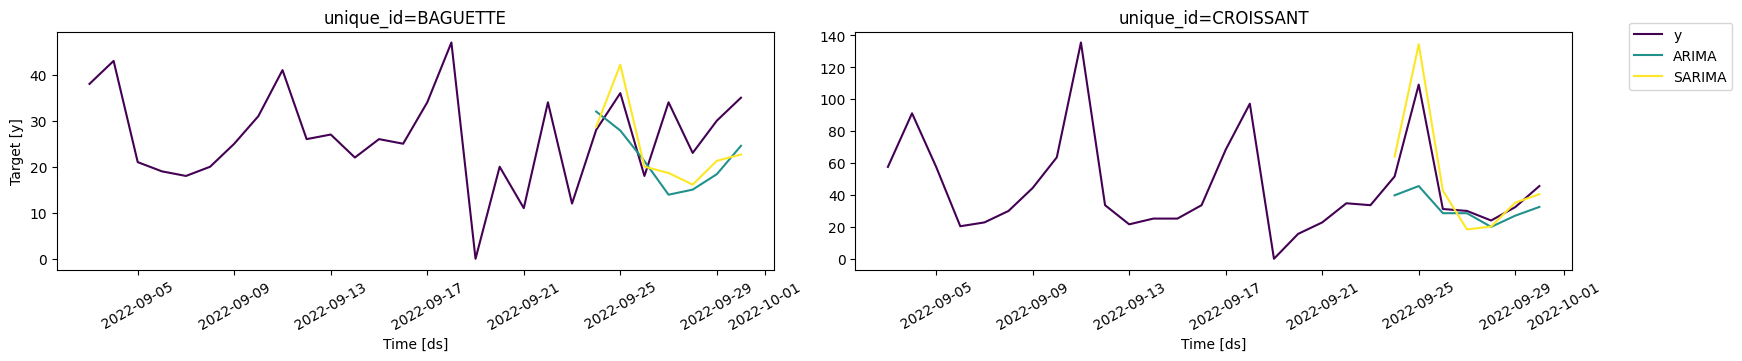

In [59]:
plot_series(
    df=df,
    forecasts_df=arima_preds,
    ids=['BAGUETTE','CROISSANT'],
    max_insample_length=28,
    palette='viridis'
)

cross validation:

In [62]:
small_df = df[df['unique_id'].isin(unique_ids)]

models = [
    SeasonalNaive(season_length=7),
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=7, alias="SARIMA")
]

sf = StatsForecast(models=models, freq="D")

# run cross validation
cv_df = sf.cross_validation(
    h = horizon, # specify the forecasting horizon
    df = small_df, # we pass the entire dataframe to the model
    n_windows = 8, # number of windows using 8 meaning we'll evaluate over 8xhorizon(7)=56 data points here
    step_size=horizon, # separation we want to enforce so we have non overlapping windows
    refit=True # determines if we want to reoptimize the model everytime the input size changes
)

cv_df.head()

,unique_id,ds,cutoff,y,SeasonalNaive,ARIMA,SARIMA
0,BAGUETTE,2022-08-06,2022-08-05,55.0,68.0,71.355195,71.584714
1,BAGUETTE,2022-08-07,2022-08-05,67.0,70.0,70.337979,78.458884
2,BAGUETTE,2022-08-08,2022-08-05,61.0,48.0,61.195002,57.001733
3,BAGUETTE,2022-08-09,2022-08-05,52.0,49.0,52.649013,49.401145
4,BAGUETTE,2022-08-10,2022-08-05,57.0,57.0,47.785876,49.725279


In [64]:
cv_df.shape, small_df.shape

((112, 7), (1274, 3))

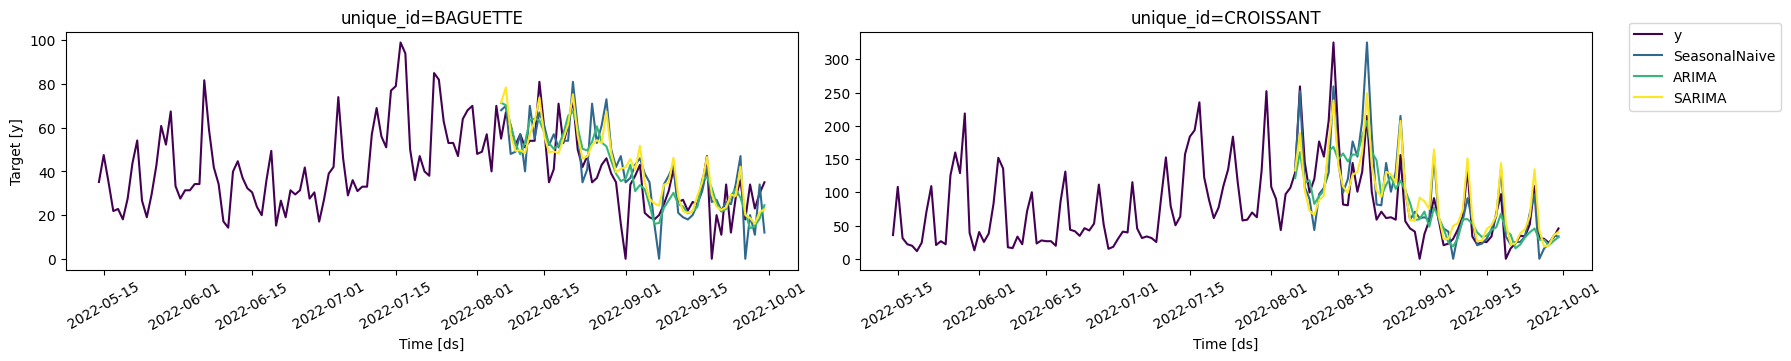

In [65]:
plot_series(
    df=small_df,
    forecasts_df=cv_df.drop(['y','cutoff'],axis=1),
    ids=["BAGUETTE","CROISSANT"],
    max_insample_length=140,
    palette="viridis"
)

In [66]:
cv_eval = evaluate(
    cv_df.drop(["cutoff"], axis=1),
    metrics=[mae]
)

cv_eval = cv_eval.drop(["unique_id"], axis=1).groupby("metric").mean().reset_index()
cv_eval

,metric,SeasonalNaive,ARIMA,SARIMA
0,mae,21.117857,21.17093,19.281295


Forecasting with exogenous features:

Forecasting with exogenous features.
- exogenous features are external variables that are not part of the time series itself
  - values of another series
  - holidays
  - any external factor
- Ex: forecasting electricity demand, features can include: outside temperature, wind speed, hour of day, etc.
- 
- Exogenous features
  - **Static features:** stay constant in time, ex a product category
  - **Historical features:** the values are known in the past, but unknown in the future
  - **Future features:** the values are known both in th epast and in the future, ex. the date of national holidays
  - for statistical models, the exogeneous features need to be future features (need to know the values in the past and future values)
- Create exogeneous features:
  - useful when we have complex seasonalities or dependecy to time features: use fourier terms for seasonality
  - encode timestaamps as features

In [67]:
# read the df again
df = pd.read_csv("https://raw.githubusercontent.com/marcopeix/youtube_tutorials/refs/heads/main/data/daily_sales_french_bakery.csv", parse_dates=['ds'])
df = df.groupby("unique_id").filter(lambda x: len(x)>= 28)
df.head()

,unique_id,ds,y,unit_price
0,12 MACARON,2022-07-13,10.0,10.0
1,12 MACARON,2022-07-14,0.0,10.0
2,12 MACARON,2022-07-15,0.0,10.0
3,12 MACARON,2022-07-16,10.0,10.0
4,12 MACARON,2022-07-17,30.0,10.0


Text(0, 0.5, 'unit price of Croissant')

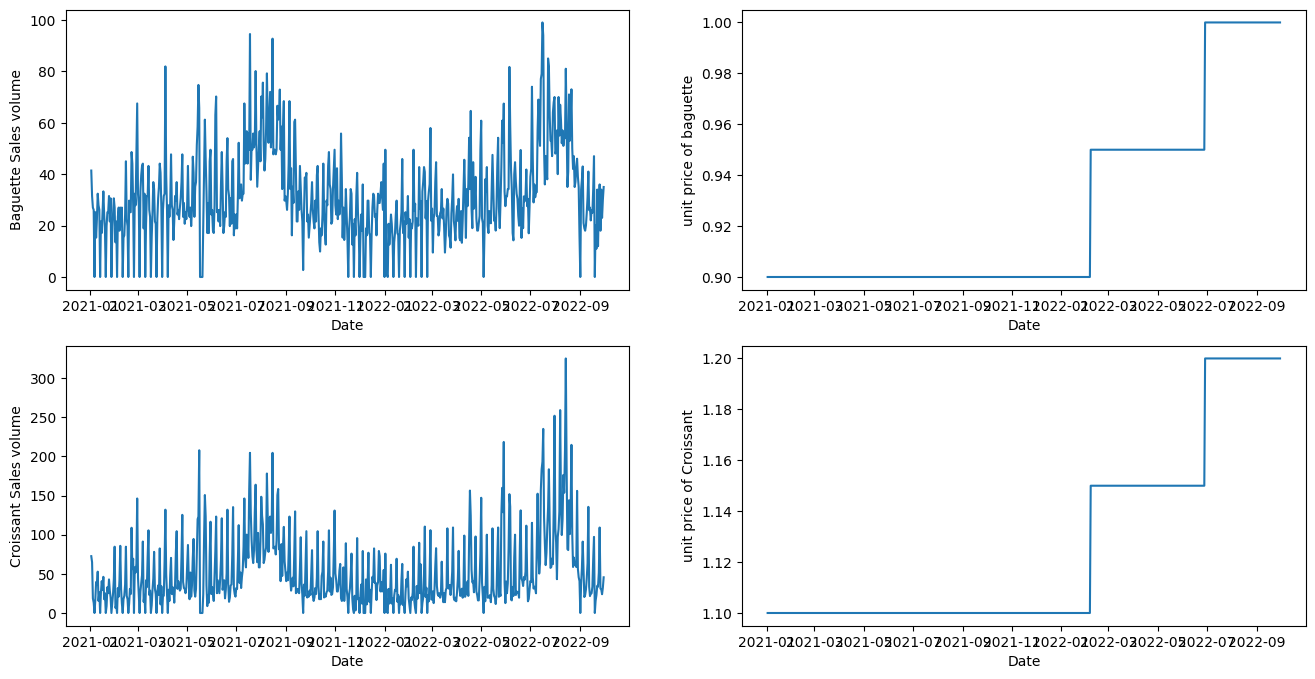

In [69]:
baguette_plot_df = df[df["unique_id"] == "BAGUETTE"]
croissant_plot_df = df[df["unique_id"] == "CROISSANT"]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(16,8))

ax1.plot(baguette_plot_df["ds"], baguette_plot_df["y"])
ax1.set_xlabel("Date")
ax1.set_ylabel("Baguette Sales volume")

ax2.plot(baguette_plot_df["ds"], baguette_plot_df["unit_price"])
ax2.set_xlabel("Date")
ax2.set_ylabel("unit price of baguette")

ax3.plot(croissant_plot_df["ds"], croissant_plot_df ["y"])
ax3.set_xlabel("Date")
ax3.set_ylabel("Croissant Sales volume")

ax4.plot(croissant_plot_df["ds"], croissant_plot_df ["unit_price"])
ax4.set_xlabel("Date")
ax4.set_ylabel("unit price of Croissant")

In [70]:
unique_ids = ["BAGUETTE", "CROISSANT"]
small_df = df[df["unique_id"].isin(unique_ids)]
test = small_df.groupby("unique_id").tail(7)
train = small_df.drop(test.index).reset_index(drop=True)

need to know the future value of the exogenous feature before predicting it
- so we take note of it

In [72]:
test.head()

,unique_id,ds,y,unit_price
714,BAGUETTE,2022-09-24,28.0,1.0
715,BAGUETTE,2022-09-25,36.0,1.0
716,BAGUETTE,2022-09-26,18.0,1.0
717,BAGUETTE,2022-09-27,34.0,1.0
718,BAGUETTE,2022-09-28,23.0,1.0


In [73]:
# take the future value of the price from the test set
futr_exog_df = test.drop(["y"], axis=1)
futr_exog_df.head()

,unique_id,ds,unit_price
714,BAGUETTE,2022-09-24,1.0
715,BAGUETTE,2022-09-25,1.0
716,BAGUETTE,2022-09-26,1.0
717,BAGUETTE,2022-09-27,1.0
718,BAGUETTE,2022-09-28,1.0


for every unique_id and timestamp, we know the future price value.

In [74]:
train.head()

,unique_id,ds,y,unit_price
0,BAGUETTE,2021-01-02,41.4,0.9
1,BAGUETTE,2021-01-03,31.5,0.9
2,BAGUETTE,2021-01-04,27.0,0.9
3,BAGUETTE,2021-01-05,26.1,0.9
4,BAGUETTE,2021-01-06,0.0,0.9


In [76]:
# define the model
models = [
    AutoARIMA(season_length=7, alias="SARIMA_exog")
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=train)

# predict with exogenous features
arima_exog_preds = sf.predict(h=horizon, X_df=futr_exog_df)

# fitting the normal sarima model without exogenous features
models = [
    AutoARIMA(season_length=7, alias="SARIMA")
]
sf = StatsForecast(models=models, freq="D")
sf.fit(df=train.drop(["unit_price"], axis=1))
arima_preds = sf.predict(h=horizon)

In [78]:
test_df = test.merge(arima_exog_preds, on=["unique_id","ds"], how="left")\
              .merge(arima_preds, on=["unique_id","ds"],how="left")
test_df

,unique_id,ds,y,unit_price,SARIMA_exog,SARIMA
0,BAGUETTE,2022-09-24,28.0,1.0,28.898807,28.657114
1,BAGUETTE,2022-09-25,36.0,1.0,42.513120,42.182374
2,BAGUETTE,2022-09-26,18.0,1.0,20.423796,20.013654
3,BAGUETTE,2022-09-27,34.0,1.0,19.066064,18.646491
4,BAGUETTE,2022-09-28,23.0,1.0,16.468724,16.114926
5,BAGUETTE,2022-09-29,30.0,1.0,21.656571,21.288018
6,BAGUETTE,2022-09-30,35.0,1.0,23.101042,22.660125
7,CROISSANT,2022-09-24,51.6,1.2,64.426277,64.011002
8,CROISSANT,2022-09-25,109.2,1.2,135.126284,134.488202
9,CROISSANT,2022-09-26,31.2,1.2,43.528691,42.735407


In [79]:
evaluate(
    test_df,
    metrics=[mae]
)

,unique_id,metric,unit_price,SARIMA_exog,SARIMA
0,BAGUETTE,mae,28.142857,7.363332,7.449083
1,CROISSANT,mae,45.085714,10.367809,10.359143


hard to distinguish between sarima w and w/o exogenous features

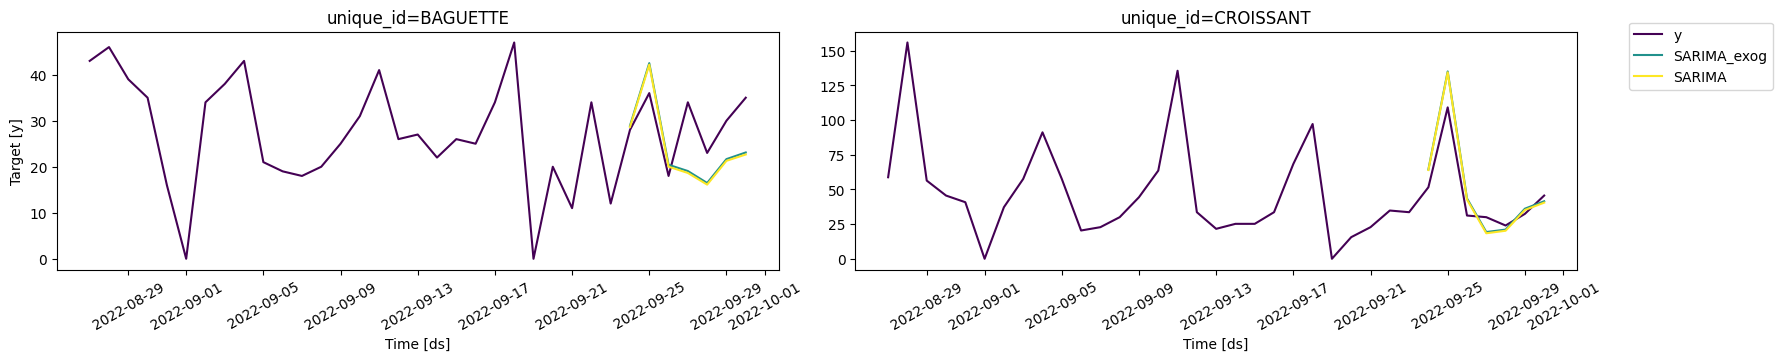

In [80]:
plot_series(
    df=train,
    forecasts_df=test_df,
    ids=["BAGUETTE","CROISSANT"],
    max_insample_length=28,
    models=["SARIMA_exog","SARIMA"],
    palette="viridis"
)

In [81]:
# running cross validation on that
models = [
    AutoARIMA(season_length=7, alias="SARIMA_exog")
]

sf = StatsForecast(models=models, freq="D")

# run cross val
cv_exog_df = sf.cross_validation(
    h = horizon,
    df = small_df,
    n_windows=8,
    step_size=horizon,
    refit=True
)

cv_exog_df.head()

,unique_id,ds,cutoff,y,SARIMA_exog
0,BAGUETTE,2022-08-06,2022-08-05,55.0,71.511192
1,BAGUETTE,2022-08-07,2022-08-05,67.0,78.457631
2,BAGUETTE,2022-08-08,2022-08-05,61.0,57.062235
3,BAGUETTE,2022-08-09,2022-08-05,52.0,49.525295
4,BAGUETTE,2022-08-10,2022-08-05,57.0,49.485231


In [82]:
# evaluation
cv_exog_eval = evaluate(
    cv_exog_df.drop(["cutoff"], axis=1),
    metrics=[mae]
)

cv_exog_eval = cv_exog_eval.drop(["unique_id"], axis=1).groupby("metric").mean().reset_index()
cv_exog_eval

,metric,SARIMA_exog
0,mae,19.210197


Creating features from timestamps

In [83]:
from functools import partial
from utilsforecast.feature_engineering import fourier, time_features, pipeline

In [84]:
features = [
    partial(fourier, season_length=7, k=2), # the higher the k, the more fourier representations we get
    partial(time_features, features=['day','week','month'])
]

small_exog_df, futr_exog_df = pipeline(df=small_df, features=features, freq="D", h=horizon)

In [85]:
small_exog_df.head()

,unique_id,ds,y,unit_price,sin1_7,sin2_7,cos1_7,cos2_7,day,week,month
84,BAGUETTE,2021-01-02,41.4,0.9,0.781832,0.974928,0.623490,-0.222521,2,53,1
85,BAGUETTE,2021-01-03,31.5,0.9,0.974928,-0.433884,-0.222521,-0.900969,3,53,1
86,BAGUETTE,2021-01-04,27.0,0.9,0.433884,-0.781831,-0.900969,0.623490,4,1,1
87,BAGUETTE,2021-01-05,26.1,0.9,-0.433884,0.781832,-0.900969,0.623490,5,1,1
88,BAGUETTE,2021-01-06,0.0,0.9,-0.974928,0.433884,-0.222521,-0.900969,6,1,1


In [86]:
futr_exog_df

,unique_id,ds,sin1_7,sin2_7,cos1_7,cos2_7,day,week,month
0,BAGUETTE,2022-10-01,0.781844,0.974919,0.623474,-0.222559,1,39,10
1,BAGUETTE,2022-10-02,0.974927,-0.433892,-0.222526,-0.900965,2,39,10
2,BAGUETTE,2022-10-03,0.433893,-0.781844,-0.900964,0.623474,3,40,10
3,BAGUETTE,2022-10-04,-0.433861,0.781800,-0.900980,0.623529,4,40,10
4,BAGUETTE,2022-10-05,-0.974933,0.433846,-0.222500,-0.900987,5,40,10
5,BAGUETTE,2022-10-06,-0.781828,-0.974931,0.623495,-0.222509,6,40,10
6,BAGUETTE,2022-10-07,-0.000009,-0.000017,1.000000,1.000000,7,40,10
7,CROISSANT,2022-10-01,0.781844,0.974919,0.623474,-0.222559,1,39,10
8,CROISSANT,2022-10-02,0.974927,-0.433892,-0.222526,-0.900965,2,39,10
9,CROISSANT,2022-10-03,0.433893,-0.781844,-0.900964,0.623474,3,40,10


In [87]:
futr_exog_df.shape, small_exog_df.shape

((14, 9), (1274, 11))

In [88]:
models = [
    AutoARIMA(season_length=7, alias="SARIMA_time_exog")
]

sf = StatsForecast(models=models, freq="D")

cv_time_exog_df = sf.cross_validation(
    h = horizon, # 7 days
    df = small_exog_df,
    n_windows=8,
    step_size=horizon,
    refit=True
)

cv_time_exog_eval = evaluate(
    cv_time_exog_df.drop(["cutoff"], axis=1),
    metrics=[mae]
)

cv_time_exog_eval = cv_time_exog_eval.drop(["unique_id"], axis=1).groupby("metric").mean().reset_index()
cv_time_exog_eval

,metric,SARIMA_time_exog
0,mae,19.502499


Prediction intervals:
- stochastic models can inherently generate prediction intervals beccause uncertainty is embedded in theor models
- ARIMA is a stochastic model because it includes an error term that follows the normal distribution

In [89]:
unique_ids = ["BAGUETTE","CROISSANT"]
small_df = df[df["unique_id"].isin(unique_ids)]
test = small_df.groupby("unique_id").tail(7)
train = small_df.drop(test.index).reset_index(drop=True)

In [90]:
train.head()

,unique_id,ds,y,unit_price
0,BAGUETTE,2021-01-02,41.4,0.9
1,BAGUETTE,2021-01-03,31.5,0.9
2,BAGUETTE,2021-01-04,27.0,0.9
3,BAGUETTE,2021-01-05,26.1,0.9
4,BAGUETTE,2021-01-06,0.0,0.9


In [92]:
test.head()

,unique_id,ds,y,unit_price
714,BAGUETTE,2022-09-24,28.0,1.0
715,BAGUETTE,2022-09-25,36.0,1.0
716,BAGUETTE,2022-09-26,18.0,1.0
717,BAGUETTE,2022-09-27,34.0,1.0
718,BAGUETTE,2022-09-28,23.0,1.0


In [ ]:
models = [
    AutoARIMA(season_length=7)
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=train)

prob_preds = sf.predict(h=horizon, X_df=test.drop(["y"], axis=1), level=[80]) # level ensures we pass the prediction level we want to see (confidence level)
# X_df ensures we provide the future value of the exogenous feature while making predictions for the forecasting horizon

....possible to also pass multiple values to the level list - to get multiple confidence intervals....

In [94]:
prob_preds

,unique_id,ds,AutoARIMA,AutoARIMA-lo-80,AutoARIMA-hi-80
0,BAGUETTE,2022-09-24,28.898807,15.640974,42.156640
1,BAGUETTE,2022-09-25,42.513120,28.327762,56.698478
2,BAGUETTE,2022-09-26,20.423796,5.891553,34.956038
3,BAGUETTE,2022-09-27,19.066064,4.290635,33.841494
4,BAGUETTE,2022-09-28,16.468724,1.483957,31.453490
5,BAGUETTE,2022-09-29,21.656571,6.481816,36.831325
6,BAGUETTE,2022-09-30,23.101042,7.751556,38.450529
7,CROISSANT,2022-09-24,64.426277,36.830139,92.022415
8,CROISSANT,2022-09-25,135.126284,103.741749,166.510819
9,CROISSANT,2022-09-26,43.528691,10.477801,76.579581


In [96]:
test_df = test.merge(prob_preds, on=["unique_id", "ds"], how="left")

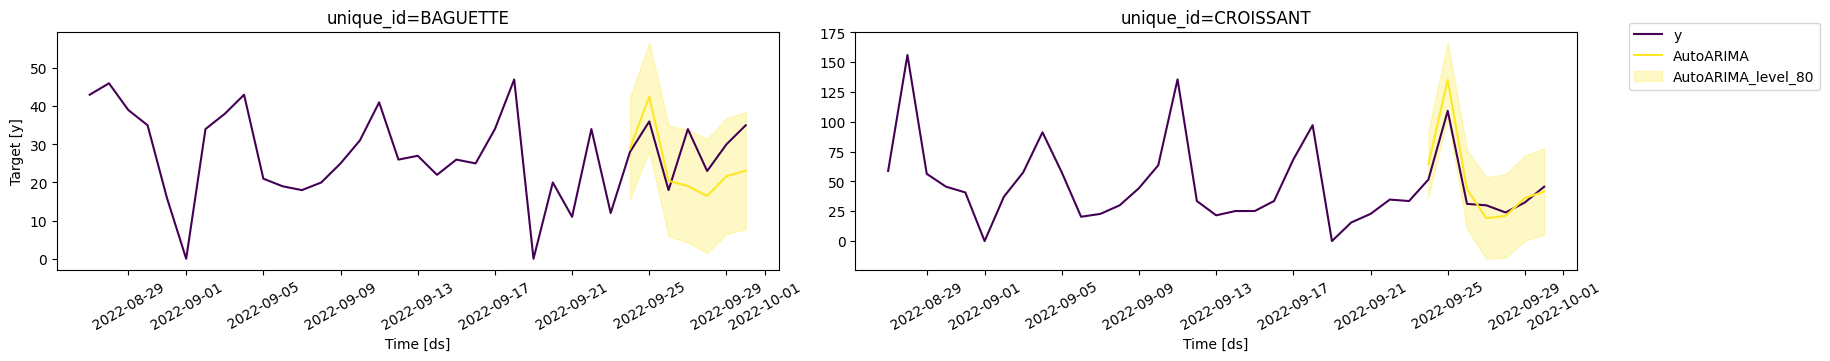

In [101]:
plot_series(
    df = train,
    forecasts_df=test_df,
    ids=["BAGUETTE","CROISSANT"],
    max_insample_length=28,
    models=["AutoARIMA"],
    level=[80],
    palette="viridis"
)

80% interval - actual vaalue has an 80% chance of falling within upper and lower bound

In [102]:
models = [
    AutoARIMA(season_length=7)
]

sf = StatsForecast(models=models, freq="D")

# run cross validation
cv_prob_df = sf.cross_validation(
    h = horizon,
    df = small_df,
    n_windows=8,
    step_size=horizon,
    refit=True,
    level=[80]
)



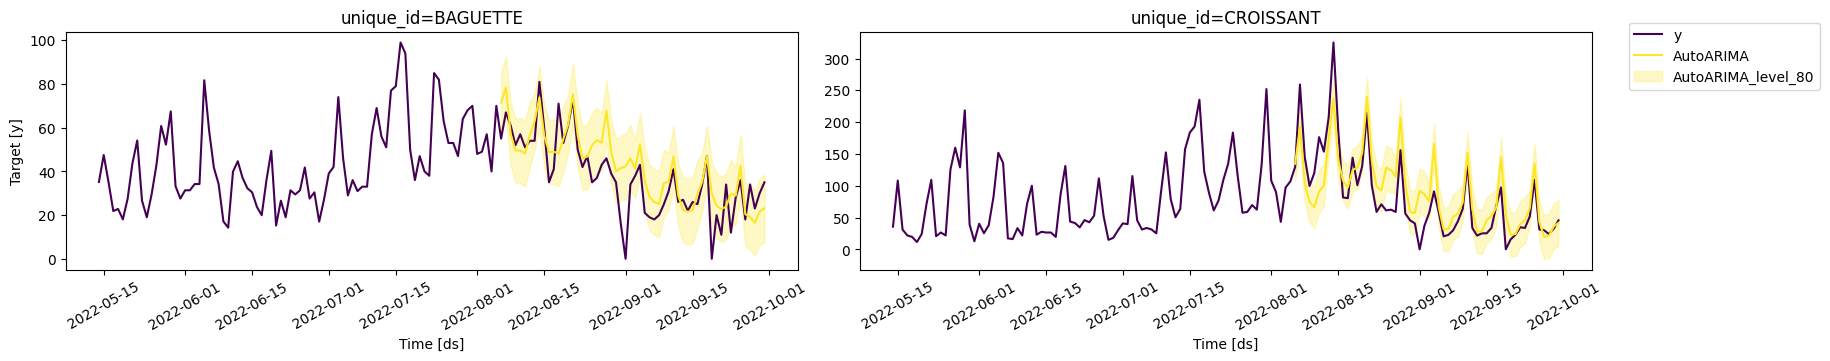

In [103]:
plot_series(
    df=small_df,
    forecasts_df=cv_prob_df.drop(["y","cutoff"], axis=1),
    ids=["BAGUETTE","CROISSANT"],
    models=["AutoARIMA"],
    max_insample_length=140,
    level=[80],
    palette="viridis"
)

Evaluation metrics:
- Depending on the type of forecasts, different eval metrics must be used
Point forecasts:
- MAE, MSE, RMSE, sMAPE, MASE
Probabilistic forecasts:
- CRPS

**EVAL METRICS:**
- MAE (mean absolute error): robust to outliers, same units as data
- CRPS: Continuous ranked probability score (CRPS)
  - Generalization of the MAE for probabilistic forecasts
  - Compares a ground truth against a cumulative distribution function
  - You care about the whole distribution

In [104]:
models = [
    AutoARIMA(season_length=7, alias="SARIMA_exog"),
    SeasonalNaive(season_length=7)
]

sf = StatsForecast(models=models, freq="D")

final_cv_df = sf.cross_validation(
    h = horizon,
    df = small_df,
    n_windows=8,
    step_size=7,
    refit=True,
    level=[80]
)

In [105]:
final_cv_df.head()

,unique_id,ds,cutoff,y,SARIMA_exog,SARIMA_exog-lo-80,SARIMA_exog-hi-80,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-hi-80
0,BAGUETTE,2022-08-06,2022-08-05,55.0,71.511192,58.278872,84.743512,68.0,50.158042,85.841958
1,BAGUETTE,2022-08-07,2022-08-05,67.0,78.457631,64.353678,92.561583,70.0,52.158042,87.841958
2,BAGUETTE,2022-08-08,2022-08-05,61.0,57.062235,42.621661,71.502809,48.0,30.158042,65.841958
3,BAGUETTE,2022-08-09,2022-08-05,52.0,49.525295,34.846705,64.203886,49.0,31.158042,66.841958
4,BAGUETTE,2022-08-10,2022-08-05,57.0,49.485231,34.606343,64.364119,57.0,39.158042,74.841958


In [106]:
temp_test = small_df.groupby("unique_id").tail(7*8) 
temp_train = small_df.drop(temp_test.index).reset_index(drop=True)

In [107]:
models = ["SARIMA_exog","SeasonalNaive"]

metrics = [
    mae,
    mse,
    rmse,
    mape,
    smape,
    partial(mase, seasonality=7),
    scaled_crps
]

final_eval = evaluate(
    final_cv_df.drop(["ds","cutoff"], axis=1),
    metrics=metrics,
    models=models,
    train_df=temp_train,
    level=[80]
)

final_eval = final_eval.drop(["unique_id"], axis=1).groupby("metric").mean().reset_index()
final_eval

,metric,SARIMA_exog,SeasonalNaive
0,mae,19.210197,21.117857
1,mape,0.328593,0.376819
2,mase,1.181424,1.328592
3,mse,792.644129,970.417143
4,rmse,24.977673,27.875413
5,scaled_crps,0.153622,0.166451
6,smape,0.168230,0.211317
